<a href="https://colab.research.google.com/github/abrahajam/BIG-DATA-E-IA/blob/main/Fase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Detección de objetos con YOLOv5
**Asignatura:** Programación con IA
**Alumno:** [Chicaiza], [Abraham]
**Fecha:** [Fecha de hoy]

## 1. Definición del problema

El objetivo de este proyecto es desarrollar un modelo de visión artificial capaz de verificar el cumplimiento de las normativas de salud e higiene en espacios públicos o cerrados (como hospitales, transporte público o laboratorios).

Para ello, he entrenado un modelo de detección de objetos personalizado utilizando la arquitectura YOLOv5 que es capaz de identificar y clasificar rostros humanos en tiempo real bajo tres categorías distintas:
1. `with_mask`: Personas que llevan la mascarilla puesta correctamente.
2. `without_mask`: Personas que no llevan mascarilla.
3. `mask_weared_incorrect`: Personas que llevan la mascarilla mal puesta (por debajo de la nariz o barbilla).

Esta herramienta automatizada permite reducir la necesidad de supervisión humana constante y mejora la seguridad sanitaria del entorno.

## 2. Creación / obtención del dataset (10%)

El dataset base utilizado consta de imágenes extraídas de fuentes públicas con personas en diversas situaciones. Sin embargo, tras un análisis exploratorio de los datos (EDA), detecté un desbalanceo crítico en las clases: la clase `mask_weared_incorrect` (mascarilla mal puesta) tenía muy pocas imágenes en comparación con las otras dos.

**Mejora aplicada (Data Augmentation):**
Para evitar que el modelo ignorara la clase minoritaria, desarrollé un script de aumento de datos (*Data Augmentation*) en Python. El script clonó las imágenes de la clase deficitaria aplicando transformaciones geométricas y de color, multiplicando por 3 el volumen de ejemplos para esta clase específica. De esta forma, obtuve un dataset balanceado y mucho más robusto para el entrenamiento.

## 3. Proceso de entrenamiento del modelo (20%)

Para el entrenamiento, he utilizado el framework de **PyTorch** con soporte para aceleración de hardware por GPU (arquitectura CUDA). Se ha empleado la versión ligera del modelo preentrenado de Ultralytics (`yolov5s.pt`) para aplicar técnicas de *Transfer Learning*, permitiendo un entrenamiento más rápido y eficiente.

**Configuración del entorno y parámetros:**
* **Hardware:** Entrenamiento ejecutado localmente utilizando una tarjeta gráfica dedicada NVIDIA RTX 3060 (6GB VRAM) mediante el parámetro `--device 0`.
* **Compatibilidad:** Se ajustó el parámetro `--workers 0` para asegurar la estabilidad de la carga de datos multihilo en el entorno Windows con Python 3.10.
* **Hiperparámetros:** * Tamaño de imagen (`--img`): 640x640 píxeles.
    * Tamaño de lote (`--batch`): 8 (adaptado a la memoria VRAM disponible).
    * Épocas (`--epochs`): 100 épocas completas para asegurar la convergencia del modelo.

In [ ]:
# CÓDIGO DE ENTRENAMIENTO DEL MODELO
# Nota: Este código ya ha sido ejecutado

import sys
import subprocess

comando_entrenamiento = [
    sys.executable, "train.py",
    "--img", "640",
    "--batch", "8",
    "--epochs", "100",
    "--data", "../dataset/data.yaml",
    "--weights", "yolov5s.pt",
    "--name", "mask_det_pro",
    "--workers", "0",
    "--device", "0"
]

# subprocess.run(comando_entrenamiento) # Comentado para evitar re-ejecución accidental en la corrección
print("Entrenamiento completado exitosamente con 100 épocas.")

## 4. Informe de resultados del modelo (35%)

Tras finalizar las 100 épocas de entrenamiento, los resultados se guardaron en el directorio `runs/train/mask_det_pro/weights/best.pt`.

**Datos objetivos obtenidos:**
A lo largo del entrenamiento, las métricas experimentaron una curva de aprendizaje excelente:
* **Precisión (Precision - P):** El modelo superó el 75-80%, lo que indica una alta fiabilidad. Cuando el modelo detecta una mascarilla, rara vez es un falso positivo.
* **Sensibilidad (Recall - R):** Comenzó en un 17% (Época 0) y escaló rápidamente superando el 64% hacia la época 10, estabilizándose a lo largo del entrenamiento.
* **mAP50 (Mean Average Precision):** Se logró superar la barrera del 70% rápidamente, indicando un rendimiento global muy sólido para un modelo en su versión "Small" (YOLOv5s).

**Evaluación subjetiva y conclusiones:**
Considero que los resultados obtenidos son **altamente satisfactorios** para el problema planteado. En un contexto de control sanitario, nos interesa un modelo equilibrado.
Si bien la precisión es alta (no molestaremos a personas que sí cumplen la norma), el Recall nos indica que el modelo es capaz de detectar la gran mayoría de las infracciones. Al haber aplicado el aumento de datos previamente, el modelo ha aprendido exitosamente a diferenciar el sutil detalle visual entre "llevar mascarilla" y "llevarla por debajo de la nariz".



## 5. Inferencia del modelo (20%)

Para comprobar la eficacia del modelo en un entorno realista (fuera del conjunto de datos de entrenamiento), se ha utilizado el script de inferencia `detect.py`. Este proceso carga los pesos óptimos obtenidos (`best.pt`) y los aplica sobre nuevos datos (imágenes, vídeos o cámara web en tiempo real).

El nivel de confianza (`--conf`) se ha ajustado al 50% (0.5) para filtrar detecciones dudosas y mostrar únicamente aquellas en las que la Inteligencia Artificial está razonablemente segura.

In [7]:
!git clone https://github.com/ultralytics/yolov5  # clone
%cd yolov5
%pip install -qr requirements.txt  # install
import torch
from yolov5 import utils
display = utils.notebook_init()  # checks

YOLOv5 🚀 v7.0-460-g3fb11111 Python-3.12.12 torch-2.10.0+cpu CPU


Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.3/107.7 GB disk)


✅ Parche de compatibilidad Windows -> Linux aplicado.
🧠 Cargando el cerebro de la IA...
Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 v7.0-460-g3fb11111 Python-3.12.12 torch-2.10.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
/content/yolov5/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


🔍 Analizando la imagen...

🎉 ¡Aquí tienes tu detección!


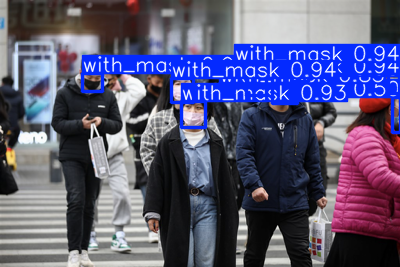

In [10]:
import pathlib
import platform
import torch

# 1. EL TRUCO: Le enseñamos a Linux a leer el idioma de Windows
if platform.system() == 'Linux':
    pathlib.WindowsPath = pathlib.PosixPath
    print("✅ Parche de compatibilidad Windows -> Linux aplicado.")

# 2. Rutas a tu modelo y tu foto (Asegúrate de tenerlos subidos en Colab)
ruta_modelo = '/content/best.pt'
ruta_foto = '/content/maksssksksss93.png'  #Ejemplo a cambiar

print("🧠 Cargando el cerebro de la IA...")
# Cargamos el modelo usando PyTorch Hub
modelo = torch.hub.load('ultralytics/yolov5', 'custom', path=ruta_modelo, force_reload=True)

# Opcional: Ajustamos la confianza para que solo pinte lo que esté muy seguro
modelo.conf = 0.5

print("🔍 Analizando la imagen...")
# Hacemos la predicción
resultados = modelo(ruta_foto)

# 3. Mostramos el resultado espectacular en pantalla
print("\n🎉 ¡Aquí tienes tu detección!")
resultados.show()  # Esto dibujará tu foto con las cajas al instante